In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import os
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(888)

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = 'data\\data_ori'
val_dir = 'data\\val'
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(val_dir), data_transforms['val'])
}
dataloaders = {x: DataLoader(
    image_datasets[x],
    batch_size=32,
    shuffle=(x=='train'),
    num_workers=8,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,             
) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

In [3]:
print(len(class_names))

10000


In [4]:
import torchvision.models as models
import torch.nn as nn
import torch
import torch.nn.functional as F

model = models.resnet18(pretrained=False)

# 印出模型架構
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

c:\Users\USER\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


First, let's print the model architecture to understand its structure:

Run the above code to see the structure of the model. Look for the final layer that produces the class scores, typically named something like classifier, head, or fc.


From the model architecture, it looks like the final classification layer is named classifier. 

To modify this layer for your custom classification task, you should replace the classifier layer with a new Linear layer that has the appropriate number of output classes for your dataset.

In [5]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

In [6]:
# Move the model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [7]:
import torch.optim as optim

# Define loss function
criterion = torch.nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.00153, weight_decay=1e-4)

# # 載入預訓練模型（如果存在）
# pretrained_path = 'custom_eff28.pth'
# if os.path.exists(pretrained_path):
#     print(f"載入預訓練模型: {pretrained_path}")
#     model.load_state_dict(torch.load(pretrained_path, map_location=device))
#     print("模型載入成功，準備繼續訓練...")
# else:
#     print("未找到預訓練模型，將從頭開始訓練...")

# # 確保模型在正確的設備上
# model = model.to(device)

In [8]:
import time
import copy
from torch.optim.lr_scheduler import CosineAnnealingLR

report_train_acc = []
report_val_acc = []
report_train_loss = []
report_val_loss = []
num_epochs = 50

# 添加學習率調度器
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

def train_model(model, criterion, optimizer, scheduler, num_epochs):  # 新增scheduler參數
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print(f'Current Learning Rate: {scheduler.get_last_lr()[0]:.6f}')  # 顯示當前學習率
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'train':
                report_train_acc.append(epoch_acc)
                report_train_loss.append(epoch_loss)
            else:
                report_val_acc.append(epoch_acc)
                report_val_loss.append(epoch_loss)
            
            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        # 在每個epoch結束後調用scheduler.step()
        scheduler.step()
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Train the model (記得傳入scheduler參數)
model = train_model(model, criterion, optimizer, scheduler, num_epochs)

# Save the model
torch.save(model.state_dict(), 'res.pth')

Epoch 0/49
Current Learning Rate: 0.001530
----------
train Loss: 9.3636 Acc: 0.0000
val Loss: 9.2154 Acc: 0.0001

Epoch 1/49
Current Learning Rate: 0.001528
----------
train Loss: 9.2105 Acc: 0.0000
val Loss: 9.2074 Acc: 0.0001

Epoch 2/49
Current Learning Rate: 0.001524
----------
train Loss: 9.0664 Acc: 0.0000
val Loss: 9.1863 Acc: 0.0002

Epoch 3/49
Current Learning Rate: 0.001516
----------
train Loss: 8.8968 Acc: 0.0000
val Loss: 10.5126 Acc: 0.0000

Epoch 4/49
Current Learning Rate: 0.001506
----------
train Loss: 8.6563 Acc: 0.0000
val Loss: 9.8416 Acc: 0.0002

Epoch 5/49
Current Learning Rate: 0.001493
----------
train Loss: 8.3538 Acc: 0.0001
val Loss: 9.9535 Acc: 0.0003

Epoch 6/49
Current Learning Rate: 0.001476
----------
train Loss: 7.9401 Acc: 0.0003
val Loss: 11.2908 Acc: 0.0006

Epoch 7/49
Current Learning Rate: 0.001457
----------
train Loss: 7.3516 Acc: 0.0004
val Loss: 14.0961 Acc: 0.0004

Epoch 8/49
Current Learning Rate: 0.001435
----------
train Loss: 6.6748 Acc:

# Testing

In [9]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import time
from tqdm import tqdm  # 添加進度條顯示
# 初始化模型架構
model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
# 載入預訓練權重
model_path = "res.pth"  # 確保檔案路徑正確
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# 設置為評估模式
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# 定義測試數據轉換 
test_transform = transforms.Compose([  
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])  

# 載入測試數據集
test_dataset = datasets.ImageFolder('data\\val', test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

# 使用動態類別數量
num_classes = len(test_dataset.classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
class_predictions = [0] * num_classes
total_correct = 0
total_samples = 0

#平均誤差
avg_error = 0.0
# 計算開始時間
start_time = time.time()

# 使用進度條跟踪測試進度
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="測試進度"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 模型預測
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        
        # 統計整體正確數
        correct = (predictions == labels).sum().item()
        total_correct += correct
        total_samples += labels.size(0)
        
        # 統計每個類別的正確數和總數
        for i in range(len(labels)):
            label = labels[i].item()
            prediction = predictions[i].item()
            class_total[label] += 1
            if label == prediction:
                class_correct[label] += 1
            avg_error += ((abs(label // 100 - prediction // 100) ** 2 + abs(label % 100 - prediction % 100) ** 2) ** 0.5)  # 計算平均誤差
            # 統計每個類別被預測的次數
            class_predictions[prediction] += 1

# 計算測試時間
test_time = time.time() - start_time

# 輸出總體準確率
overall_accuracy = 100 * total_correct / total_samples
print(f'總體準確率: {overall_accuracy:.2f}% ({total_correct}/{total_samples})')
print(f'測試完成，耗時: {test_time:.2f} 秒')

# 輸出每個類別的準確率
print("\n各類別準確率:")
for i in range(len(class_names)):
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f'類別 {i}: {accuracy:.2f}% ({class_correct[i]}/{class_total[i]})')

# 輸出每個類別被預測到的次數
print("\n各類別被預測次數:")
for i in range(len(class_names)):
    print(f'類別 {i}: {class_predictions[i]}')
# 輸出平均誤差
print(f'\n平均誤差: {avg_error / total_samples:.4f}')

測試進度: 100%|██████████| 157/157 [00:12<00:00, 12.52it/s]

總體準確率: 1.45% (145/10000)
測試完成，耗時: 12.55 秒

各類別準確率:
類別 0: 0.00% (0/1)
類別 1: 0.00% (0/1)
類別 2: 0.00% (0/1)
類別 3: 0.00% (0/1)
類別 4: 0.00% (0/1)
類別 5: 0.00% (0/1)
類別 6: 0.00% (0/1)
類別 7: 0.00% (0/1)
類別 8: 0.00% (0/1)
類別 9: 0.00% (0/1)
類別 10: 0.00% (0/1)
類別 11: 0.00% (0/1)
類別 12: 0.00% (0/1)
類別 13: 0.00% (0/1)
類別 14: 0.00% (0/1)
類別 15: 0.00% (0/1)
類別 16: 0.00% (0/1)
類別 17: 0.00% (0/1)
類別 18: 0.00% (0/1)
類別 19: 0.00% (0/1)
類別 20: 0.00% (0/1)
類別 21: 100.00% (1/1)
類別 22: 0.00% (0/1)
類別 23: 0.00% (0/1)
類別 24: 0.00% (0/1)
類別 25: 0.00% (0/1)
類別 26: 0.00% (0/1)
類別 27: 0.00% (0/1)
類別 28: 0.00% (0/1)
類別 29: 0.00% (0/1)
類別 30: 0.00% (0/1)
類別 31: 0.00% (0/1)
類別 32: 0.00% (0/1)
類別 33: 0.00% (0/1)
類別 34: 0.00% (0/1)
類別 35: 0.00% (0/1)
類別 36: 0.00% (0/1)
類別 37: 0.00% (0/1)
類別 38: 0.00% (0/1)
類別 39: 0.00% (0/1)
類別 40: 0.00% (0/1)
類別 41: 0.00% (0/1)
類別 42: 0.00% (0/1)
類別 43: 0.00% (0/1)
類別 44: 0.00% (0/1)
類別 45: 0.00% (0/1)
類別 46: 0.00% (0/1)
類別 47: 0.00% (0/1)
類別 48: 0.00% (0/1)
類別 49: 0.00% (0/1)
類別 50: 

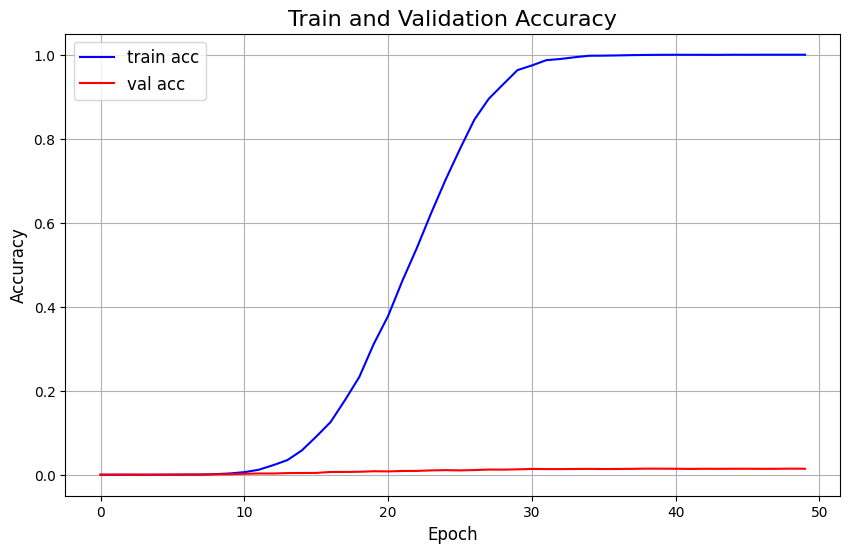

In [10]:
import matplotlib.pyplot as plt
import numpy as np

train_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in report_train_acc])
val_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in report_val_acc])
epochs = list(range(len(train_acc)))

plt.figure(figsize=(10,6))
plt.plot(epochs, train_acc, 'b-', label='train acc')
plt.plot(epochs, val_acc, 'r-', label='val acc')
plt.title('Train and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()